In [1]:
from pathlib import Path
Path().resolve()

WindowsPath('C:/Users/rshub/Desktop/projects/ABOIA/data/analysis')

In [2]:
import sys
from pathlib import Path

ROOT = Path().resolve().parents[1]  # go two levels up safely
sys.path.append(str(ROOT))

# print("ROOT:", ROOT)
# print("Contains app folder?", (ROOT / "app").exists())

In [3]:
from app.utils.data_cleaning import load_olist_tables

orders, items, customers = load_olist_tables()

orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [4]:
items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [5]:
customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [6]:
print("Orders:", orders.shape)
print("Items:", items.shape)
print("Customers:", customers.shape)

Orders: (99441, 8)
Items: (112650, 7)
Customers: (99441, 5)


In [7]:
#Customer_unique_id-> actual customer; customer_id-> per order
orders_full = orders.merge(
    customers[["customer_id", "customer_unique_id"]],
    on="customer_id",
    how="left"
)

In [8]:
#Is order_id unique in orders?
orders["order_id"].nunique(), len(orders)
#One row = one checkout event
#order_id is a primary key in olist_orders_dataset

(99441, 99441)

In [9]:
#Check missing values
orders.isnull().sum().sort_values(ascending=False)

order_delivered_customer_date    2965
order_delivered_carrier_date     1783
order_approved_at                 160
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_estimated_delivery_date       0
dtype: int64

In [10]:
items.isnull().sum().sort_values(ascending=False)

order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

In [11]:
customers.isnull().sum().sort_values(ascending=False)

customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

In [12]:
#How many items per order
items_per_order = items.groupby("order_id").size()
items_per_order.sort_values(ascending=False).head(10)

order_id
8272b63d03f5f79c56e9e4120aec44ef    21
1b15974a0141d54e36626dca3fdc731a    20
ab14fdcfbe524636d65ee38360e22ce8    20
9ef13efd6949e4573a18964dd1bbe7f5    15
428a2f660dc84138d969ccd69a0ab6d5    15
9bdc4d4c71aa1de4606060929dee888c    14
73c8ab38f07dc94389065f7eba4f297a    14
37ee401157a3a0b28c9c6d0ed8c3b24b    13
2c2a19b5703863c908512d135aa6accc    12
c05d6a79e55da72ca780ce90364abed9    12
dtype: int64

In [13]:
#Statistical proof of how orders behave
items_per_order.describe()
#Most orders are single-item; But a small percentage are very large.

count    98666.000000
mean         1.141731
std          0.538452
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max         21.000000
dtype: float64

In [14]:
#Order_id that exist in order table but not in item table-> maybe those orders got cancelled or failed orders
orders_without_items = set(orders["order_id"]) - set(items["order_id"])
len(orders_without_items)

775

In [ ]:
#For each customer on each day: How many orders did they place on the same day?
orders_full["date"] = orders_full["order_purchase_timestamp"].dt.date

orders_full.groupby(
    ["date", "customer_unique_id"]).size().sort_values(ascending=False).head(20)


date        customer_unique_id              
2017-01-05  12f5d6e1cbf93dafd9dcc19095df0b3d    6
            83e7958a94bd7f74a9414d8782f87628    4
            728e4a7d0db4845270091ded0923c71f    3
2018-02-24  b4e4f24de1e8725b74e4a1f4975116ed    3
2018-03-31  66980c3775537536f77b434d74e520f5    3
2018-02-14  d3882d7abd0c66064d740d7ed04dd1ef    3
2017-12-01  3e43e6105506432c953e165fb2acf44c    3
2017-08-30  46958f708ade6b6a88b2e5aca1e66de5    3
2018-05-27  9aae8213ff9bc04cc3ce48b85f43a173    3
2017-02-06  a239b8e2fbce33780f1f1912e2ee5275    3
2018-02-27  b2bd387fdc3cf05931f0f897d607dc88    3
2017-12-04  b59e4bb4efe81ba0f7d30cff6734f9a2    3
2017-05-06  06a52782a04f0086d16b9c22d0e29438    3
2017-08-22  f34cd7fd85a1f8baff886edf09567be3    3
2018-06-01  e13e8b789e5a8e6fe1445f924a4ed4f6    3
2017-06-14  bb58670190dba4e9b320f84cb98317a3    3
2018-02-06  5bdb6f56a8fb4272b802f504bb6d1287    3
2017-01-26  2e43e031f10de28e557c35ef668f9396    3
2018-04-19  d6df1c8cb71c59d9b52d828dc6d0f5b3    3
2017-

In [ ]:
#For each real user: How many orders did this person place in the entire dataset?
orders_full.groupby("customer_unique_id").size().describe()
#Has repeat customers/buyers

count    96096.000000
mean         1.034809
std          0.214384
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max         17.000000
dtype: float64

In [17]:
daily_check = (
    orders_full.groupby("date")
    .agg(
        orders=("order_id", "nunique"),
        users=("customer_unique_id", "nunique"),
    )
    .reset_index()
)

daily_check.head()


,date,orders,users
0,2016-09-04,1,1
1,2016-09-05,1,1
2,2016-09-13,1,1
3,2016-09-15,1,1
4,2016-10-02,1,1


In [18]:
(daily_check["orders"] == daily_check["users"]).value_counts()

False    420
True     214
Name: count, dtype: int64

In [ ]:
#Timestamp of data
orders["order_purchase_timestamp"].min(), orders["order_purchase_timestamp"].max()


(Timestamp('2016-09-04 21:15:19'), Timestamp('2018-10-17 17:30:18'))

In [ ]:
#Timestamp of orders year-wise
orders["order_purchase_timestamp"].dt.year.value_counts()


order_purchase_timestamp
2018    54011
2017    45101
2016      329
Name: count, dtype: int64

In [ ]:
#Price vs freight
items[["price", "freight_value"]].describe()

,price,freight_value
count,112650.000000,112650.000000
mean,120.653739,19.990320
std,183.633928,15.806405
min,0.850000,0.000000
25%,39.900000,13.080000
50%,74.990000,16.260000
75%,134.900000,21.150000
max,6735.000000,409.680000


In [ ]:
#Daily volume of orders
daily_orders = orders_full.groupby("date")["order_id"].nunique()
daily_orders.describe()

count     634.000000
mean      156.847003
std        94.224817
min         1.000000
25%        96.000000
50%       148.000000
75%       215.750000
max      1176.000000
Name: order_id, dtype: float64

<Axes: xlabel='date'>

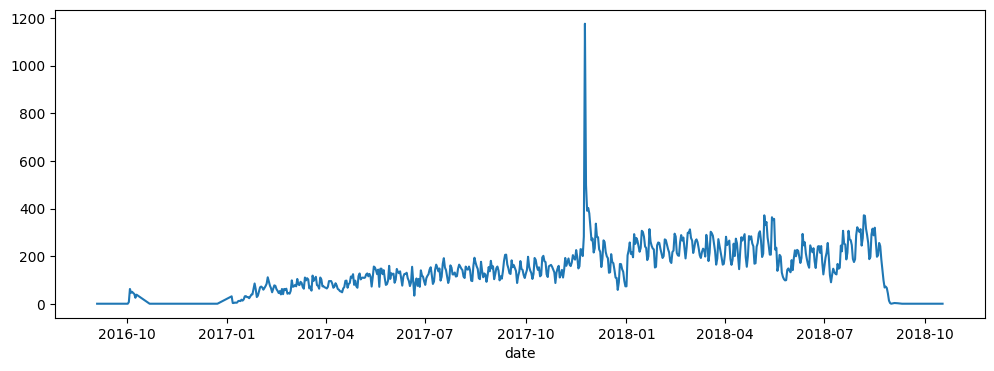

In [27]:
daily_orders.plot(figsize=(12,4))


In [30]:
#Orders without customer, if any
orders_full["customer_unique_id"].isnull().sum()

0

In [31]:
#Items without matching order, if any
len(set(items["order_id"]) - set(orders["order_id"]))

0

In [32]:
#Daily items sold vs daily orders
merged = items.merge(
    orders_full[["order_id", "date"]],
    on="order_id"
)

daily_items = merged.groupby("date").size()
daily_orders = orders_full.groupby("date")["order_id"].nunique()

(daily_items / daily_orders).describe()

count    616.000000
mean       1.131601
std        0.108035
min        0.250000
25%        1.095652
50%        1.125000
75%        1.157274
max        3.000000
dtype: float64

In [33]:
#Distribution of orders per day
orders_full.groupby("date")["order_id"].nunique().describe()

count     634.000000
mean      156.847003
std        94.224817
min         1.000000
25%        96.000000
50%       148.000000
75%       215.750000
max      1176.000000
Name: order_id, dtype: float64